# Módulo 1 — Monte Carlo puro

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas  
**Autor:** Jorge Rodríguez Lázaro  
**Última actualización:** 2026-06-30

---

## Objetivo del módulo

Este notebook construye desde cero la intuición del **método de Monte Carlo** mediante tres ejercicios sobre problemas con respuesta conocida. Usamos problemas resueltos (π, el TCL) precisamente porque conocer la respuesta exacta nos permite **validar el método**: si funciona donde sabemos lo que tiene que salir, podemos confiar en él donde no lo sabemos.

El objetivo real es:

1. Ver cómo **el azar bien empleado** resuelve problemas deterministas.
2. Cuantificar el **error estadístico** del estimador y observar su comportamiento.
3. Construir las dos piezas conceptuales que sostendrán todo el resto del proyecto: **la simulación repetida + el promedio** (Monte Carlo) y **la trayectoria aleatoria** (random walk → movimiento browniano).

## Estructura

| Sección | Tema | Conexión con el proyecto |
|---------|------|-----------------------------| 
| 1 | Estimación de π por Monte Carlo | El "hola mundo" del método. Introduce convergencia y error estándar. |
| 2 | Paseo aleatorio unidimensional | Base intuitiva del movimiento browniano (Módulo 2). |
| 3 | Teorema Central del Límite en simulación | Justifica por qué promediar simulaciones funciona y por qué la velocidad de convergencia es $O(1/\sqrt{N})$. |

## Referencias

- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, cap. 1.
- Robert, C. P. & Casella, G. (2004). *Monte Carlo Statistical Methods*, cap. 1–2.

---

# Sección 1 — Estimación de π por Monte Carlo

## 1.1 Planteamiento geométrico

Consideremos el cuadrado $Q = [-1, 1] \times [-1, 1]$ y el círculo unidad $C = \{(x,y) \in \mathbb{R}^2 : x^2 + y^2 \le 1\}$ inscrito en él.

- **Área del cuadrado:** $\text{Área}(Q) = 2 \cdot 2 = 4$
- **Área del círculo:** $\text{Área}(C) = \pi \cdot 1^2 = \pi$

Por el principio de Laplace continuo (probabilidad geométrica):

$$
\mathbb{P}\big((U, V) \in C\big) = \frac{\text{Área}(C)}{\text{Área}(Q)} = \frac{\pi}{4}
$$

donde $(U, V)$ es un punto elegido **uniformemente al azar** en $Q$.

## 1.2 De la geometría a la probabilidad

Repetimos el experimento $N$ veces. En cada repetición $i$ generamos un punto aleatorio $(U_i, V_i)$ uniforme en $Q$ y definimos la variable indicadora:

$$
Z_i = \mathbf{1}\{U_i^2 + V_i^2 \le 1\}
$$

$Z_i$ es una función del punto aleatorio $(U_i, V_i)$ y por tanto es ella misma una variable aleatoria. Como solo toma valores en $\{0, 1\}$, es una **Bernoulli** de parámetro $p = \pi/4$:

$$
Z_i = \begin{cases} 1 & \text{si } (U_i, V_i) \in C \\ 0 & \text{si } (U_i, V_i) \notin C \end{cases}
\qquad \mathbb{E}[Z_i] = p = \frac{\pi}{4}
$$

Las variables $Z_1, Z_2, \ldots, Z_N$ son **i.i.d.** (independientes porque cada punto se genera de forma independiente; idénticamente distribuidas porque todas siguen la misma Bernoulli($\pi/4$)).

## 1.3 Ley de los Grandes Números y estimador

Sea $\bar{Z}_N = \frac{1}{N}\sum_{i=1}^{N} Z_i$ el promedio muestral. Por la **LGN débil** (Khinchin), para todo $\varepsilon > 0$:

$$
\mathbb{P}\!\left(\left|\bar{Z}_N - \frac{\pi}{4}\right| < \varepsilon\right) \xrightarrow{N \to \infty} 1
$$

Es decir, para cualquier $\varepsilon$ fijo por pequeño que sea, la probabilidad de que el promedio esté a menos de $\varepsilon$ de $\pi/4$ tiende a 1 conforme $N \to \infty$. La **LGN fuerte** (Borel–Cantelli) refuerza esto a convergencia casi segura:

$$
\bar{Z}_N \xrightarrow{\text{c.s.}} \frac{\pi}{4}
$$

Despejando, el **estimador de Monte Carlo** para π es:

$$
\boxed{\hat{\pi}_N = 4\,\bar{Z}_N = \frac{4}{N}\sum_{i=1}^{N} \mathbf{1}\{U_i^2 + V_i^2 \le 1\}}
$$

## 1.4 ¿Qué precisión esperamos?

$\hat{\pi}_N$ es una variable aleatoria con varianza finita. Usando $\text{Var}(Z_i) = p(1-p)$ con $p = \pi/4$:

$$
\text{Var}(\hat{\pi}_N) = 16 \cdot \frac{\text{Var}(Z_i)}{N} = \frac{16\,p(1-p)}{N} = \frac{\pi(4-\pi)}{N}
$$

Y su **error estándar** (desviación típica del estimador):

$$
\text{SE}(\hat{\pi}_N) = \sqrt{\frac{\pi(4-\pi)}{N}} \approx \frac{1.642}{\sqrt{N}}
$$

**Lectura práctica:** para reducir el error a la mitad hay que **cuadruplicar** $N$. Ese ritmo $O(1/\sqrt{N})$ es la velocidad de convergencia característica de Monte Carlo — lenta, pero independiente de la dimensión del problema, lo que lo hace único para problemas de alta dimensión.

## 1.4 Implementación

Empezamos importando lo necesario y fijando una semilla para que los resultados sean reproducibles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generador de números pseudoaleatorios moderno de NumPy.
# Fijamos semilla para que el notebook sea 100% reproducible.
rng = np.random.default_rng(seed=42)

## 1.5 Implementación vectorizada

Generamos los N puntos **todos a la vez** como arrays de NumPy en lugar de usar un bucle Python. Esto es entre 10 y 100 veces más rápido y es el estilo estándar en computación científica.

In [2]:
def estimar_pi(N, rng):
    U = rng.uniform(-1, 1, N)       # N coordenadas x uniformes en [-1, 1] --> Array de las coordenadas x
    V = rng.uniform(-1, 1, N)       # N coordenadas y uniformes en [-1, 1] --> Array de las coordenadas y
    dentro = (U**2 + V**2) <= 1     # True si el punto cae dentro del círculo --> vector de Zi 
    return 4 * np.mean(dentro)      # Z̄_N * 4 = estimación de π

## 1.6 Primera prueba: ¿converge a π?

Llamamos a `estimar_pi` con distintos valores de N y comparamos cada estimación con el valor real de π junto al error estándar teórico derivado en la sección 1.4.

In [3]:
PI_REAL = np.pi

valores_N = [100, 1_000, 10_000, 100_000, 1_000_000]

print(f"{'N':>10}  {'π estimado':>12}  {'error real':>12}  {'SE teórico':>12}")
print("-" * 52)

for N in valores_N:
    estimacion = estimar_pi(N, rng)
    error_real = abs(estimacion - PI_REAL)
    se_teorico = np.sqrt(np.pi * (4 - np.pi) / N)
    print(f"{N:>10,}  {estimacion:>12.6f}  {error_real:>12.6f}  {se_teorico:>12.6f}")

         N    π estimado    error real    SE teórico
----------------------------------------------------
       100      3.120000      0.021593      0.164218
     1,000      3.068000      0.073593      0.051930
    10,000      3.132800      0.008793      0.016422
   100,000      3.143920      0.002327      0.005193
 1,000,000      3.143664      0.002071      0.001642


## 1.7 Visualizaciones

### Gráfico 1 — Distribución de puntos

2000 puntos generados uniformemente en el cuadrado, coloreados según si caen dentro (azul) o fuera (rojo) del círculo. La proporción de puntos azules es aproximadamente π/4.

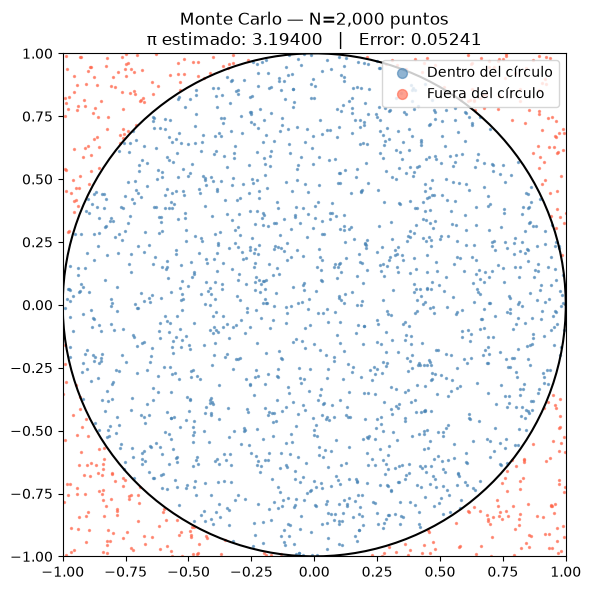

In [4]:
N_viz = 2_000
U_viz = rng.uniform(-1, 1, N_viz)
V_viz = rng.uniform(-1, 1, N_viz)
dentro_viz = (U_viz**2 + V_viz**2) <= 1
pi_viz = 4 * np.mean(dentro_viz)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(U_viz[dentro_viz],  V_viz[dentro_viz],  s=2, color='steelblue', alpha=0.6, label='Dentro del círculo')
ax.scatter(U_viz[~dentro_viz], V_viz[~dentro_viz], s=2, color='tomato',    alpha=0.6, label='Fuera del círculo')
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1.5)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
ax.set_title(f'Monte Carlo — N={N_viz:,} puntos\nπ estimado: {pi_viz:.5f}   |   Error: {abs(pi_viz - np.pi):.5f}')
ax.legend(markerscale=5, loc='upper right')
plt.tight_layout()
plt.show()

### Gráfico 2 — Convergencia del estimador

Error real para 60 valores de N en escala logarítmica, comparado con el SE teórico. En escala log-log, ambas curvas deberían seguir una recta de pendiente −1/2, la firma del ritmo O(1/√N).

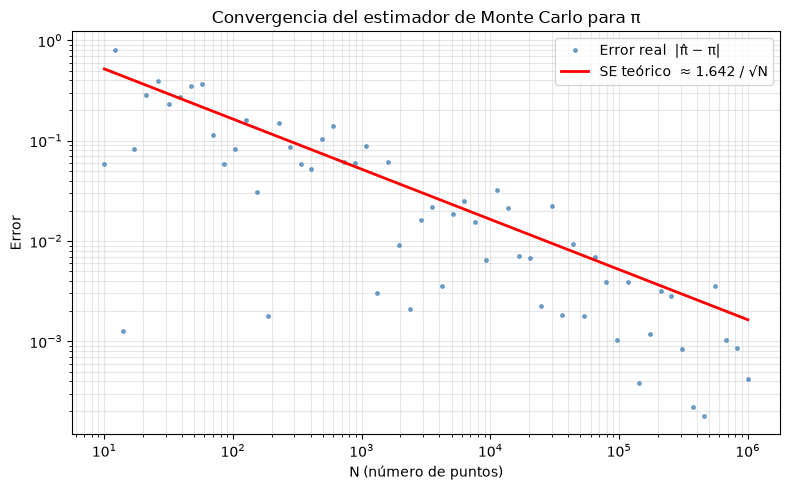

In [5]:
N_vals  = np.unique(np.logspace(1, 6, 60).astype(int))
errores = np.array([abs(estimar_pi(N, rng) - np.pi) for N in N_vals])
se_vals = np.sqrt(np.pi * (4 - np.pi) / N_vals)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(N_vals, errores, '.', color='steelblue', alpha=0.7, markersize=5, label='Error real  |π̂ − π|')
ax.loglog(N_vals, se_vals, 'r-', linewidth=2,                               label='SE teórico  ≈ 1.642 / √N')
ax.set_xlabel('N (número de puntos)')
ax.set_ylabel('Error')
ax.set_title('Convergencia del estimador de Monte Carlo para π')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 1.8 Cierre de la sección — balance honesto

### Resultados obtenidos

El estimador de Monte Carlo $\hat{\pi}_N = 4\bar{Z}_N$ satisface las siguientes propiedades:

- **Consistencia:** por la LGN fuerte (Kolmogorov), $\hat{\pi}_N \xrightarrow{\text{c.s.}} \pi$ cuando $N \to \infty$, dado que las $Z_i$ son i.i.d. con $\mathbb{E}[Z_i] = \pi/4 < \infty$.
- **Insesgadez:** $\mathbb{E}[\hat{\pi}_N] = \pi$ para todo $N$ finito, al ser $\hat{\pi}_N = 4\bar{Z}_N$ y $\mathbb{E}[\bar{Z}_N] = \pi/4$.
- **Tasa de convergencia:** $\text{SE}(\hat{\pi}_N) = \sqrt{\pi(4-\pi)/N} = O(N^{-1/2})$, confirmado empíricamente mediante el gráfico log-log de la sección 1.7.

### Limitaciones

**Velocidad de convergencia.** El ritmo $O(N^{-1/2})$ es intrínseco a cualquier estimador de Monte Carlo basado en $N$ muestras i.i.d. — es consecuencia directa del Teorema Central del Límite (sección 3). Para reducir el error en un orden de magnitud se requiere incrementar $N$ en dos órdenes. Métodos de cuadratura deterministas (e.g. integración de Gauss-Legendre) alcanzan tasas de convergencia exponencial en dimensión baja, lo que los hace superiores para este problema unidimensional concreto.

**Naturaleza estocástica.** $\hat{\pi}_N$ es una variable aleatoria: dos ejecuciones con distintas semillas producen estimaciones distintas. Toda estimación de Monte Carlo debe ir acompañada de su error estándar para ser interpretable; un único número sin cuantificación de la incertidumbre carece de valor estadístico.

**Alcance del ejemplo.** La estimación de $\pi$ se emplea aquí como banco de pruebas del método, no como aplicación de interés práctico. Su valor reside en que la solución exacta es conocida, permitiendo validar tanto la implementación como la fórmula del error estándar. La ventaja competitiva de Monte Carlo se manifiesta en problemas de alta dimensión o con integrales sin forma cerrada, donde los métodos deterministas resultan inviables.

### Estructura general del método

Esta sección ilustra el esquema canónico de Monte Carlo, que se repetirá en los módulos sucesivos:

$$
\mu = \mathbb{E}[f(X)] \approx \frac{1}{N}\sum_{i=1}^{N} f(X_i), \qquad X_i \overset{\text{i.i.d.}}{\sim} \mathbb{P}_X
$$

En la Sección 1, $f = \mathbf{1}_C$ y $\mu = \pi/4$. En el Módulo 3, $f$ será el payoff descontado de una opción europea y $\mu$ su precio justo bajo la medida de riesgo neutral — el mismo esquema con una función de mayor complejidad financiera.

---

# Sección 2 — Paseo Aleatorio Unidimensional

## 2.1 Planteamiento matemático

### Definición

Sea $\varepsilon_1, \varepsilon_2, \ldots, \varepsilon_n$ una sucesión de variables aleatorias i.i.d. con distribución:

$$
\varepsilon_i = \begin{cases} +1 & \text{con probabilidad } \tfrac{1}{2} \\ -1 & \text{con probabilidad } \tfrac{1}{2} \end{cases}
$$

El **paseo aleatorio simple** es el proceso estocástico $\{S_n\}_{n \ge 0}$ definido por:

$$
S_0 = 0, \qquad S_n = \sum_{i=1}^{n} \varepsilon_i
$$

$S_n$ representa la posición tras $n$ pasos. Es una variable aleatoria definida sobre el espacio muestral de todas las secuencias posibles de $n$ lanzamientos — cada $\varepsilon_i$ y el propio $S_n$ son funciones sobre ese espacio muestral común.

### Propiedades

**Media:** Como $\mathbb{E}[\varepsilon_i] = \tfrac{1}{2}(+1) + \tfrac{1}{2}(-1) = 0$ y los pasos son independientes:

$$
\mathbb{E}[S_n] = \sum_{i=1}^{n} \mathbb{E}[\varepsilon_i] = 0
$$

En promedio, el caminante no se desplaza en ninguna dirección. Esto no significa que cada trayectoria concreta se quede en el origen — significa que si promedias las posiciones finales de muchas trayectorias independientes, el resultado tiende a 0.

**Varianza:** Como $\text{Var}(\varepsilon_i) = \mathbb{E}[\varepsilon_i^2] - \mathbb{E}[\varepsilon_i]^2 = 1 - 0 = 1$ y los pasos son independientes:

$$
\text{Var}(S_n) = \sum_{i=1}^{n} \text{Var}(\varepsilon_i) = n \qquad \Rightarrow \qquad \text{DE}(S_n) = \sqrt{n}
$$

La dispersión típica crece como $\sqrt{n}$: con 100 pasos el caminante está típicamente a distancia 10 del origen; con 10.000 pasos, a distancia 100.

### Movimiento browniano

El **movimiento browniano estándar** (o proceso de Wiener) es un proceso estocástico continuo $\{W_t\}_{t \ge 0}$ que satisface las siguientes propiedades:

1. $W_0 = 0$ — el proceso empieza en el origen con certeza.
2. **Incrementos independientes:** para cualquier $0 \le s < t$, el incremento $W_t - W_s$ es independiente de toda la historia del proceso hasta el instante $s$.
3. **Incrementos gaussianos:** $W_t - W_s \sim \mathcal{N}(0,\, t - s)$ — el incremento entre dos instantes sigue una distribución normal con media 0 y varianza igual al tiempo transcurrido $t - s$.
4. **Trayectorias continuas:** las realizaciones de $W_t$ son funciones continuas del tiempo, sin saltos.

La propiedad 3 implica que $\text{DE}(W_t) = \sqrt{t}$: igual que en el paseo aleatorio la dispersión crecía como $\sqrt{n}$, en el movimiento browniano la dispersión crece como $\sqrt{t}$. Es el mismo comportamiento, ahora en tiempo continuo.

### Conexión con el movimiento browniano

El paseo aleatorio es la versión **discreta** del movimiento browniano. Si tomamos pasos de tamaño $\sqrt{\Delta t}$ cada $\Delta t$ segundos y hacemos $\Delta t \to 0$, el proceso converge (en distribución) al movimiento browniano estándar $W_t$ — resultado conocido como el **teorema de invariancia de Donsker** (1951).

El tamaño del paso es $\sqrt{\Delta t}$ y no $\Delta t$ porque la varianza acumula linealmente: $n$ pasos de varianza $\Delta t$ cada uno producen varianza total $n \cdot \Delta t = t$, que es exactamente lo que exige la propiedad 3 del movimiento browniano.

Esta conexión es el puente entre la Sección 2 y el Módulo 2: el movimiento browniano geométrico (GBM) que modela precios de activos es, en esencia, un paseo aleatorio en tiempo continuo con escala $\sqrt{dt}$.

## 2.2 Implementación vectorizada

Simulamos `n_trayectorias` paseos simultáneamente generando una matriz de pasos de dimensiones `(n_trayectorias, n_pasos)` y acumulando con `cumsum` a lo largo del eje de los pasos.

In [6]:
def simular_paseos(n_pasos, n_trayectorias, rng):
    # Matriz (n_trayectorias x n_pasos) de pasos +1 / -1
    pasos = rng.choice([-1, 1], size=(n_trayectorias, n_pasos))
    # cumsum acumula los pasos fila a fila: columna k = S_k
    trayectorias = np.cumsum(pasos, axis=1)
    # Añadimos S_0 = 0 al inicio de cada trayectoria
    ceros = np.zeros((n_trayectorias, 1))
    return np.hstack([ceros, trayectorias])

## 2.3 Visualizaciones

### Gráfico 1 — Trayectorias del paseo aleatorio

Trazamos 50 trayectorias independientes de 500 pasos. La envolvente $\pm\sqrt{n}$ marca la desviación típica teórica en cada instante — la mayoría de las trayectorias deben quedar dentro de esa banda.

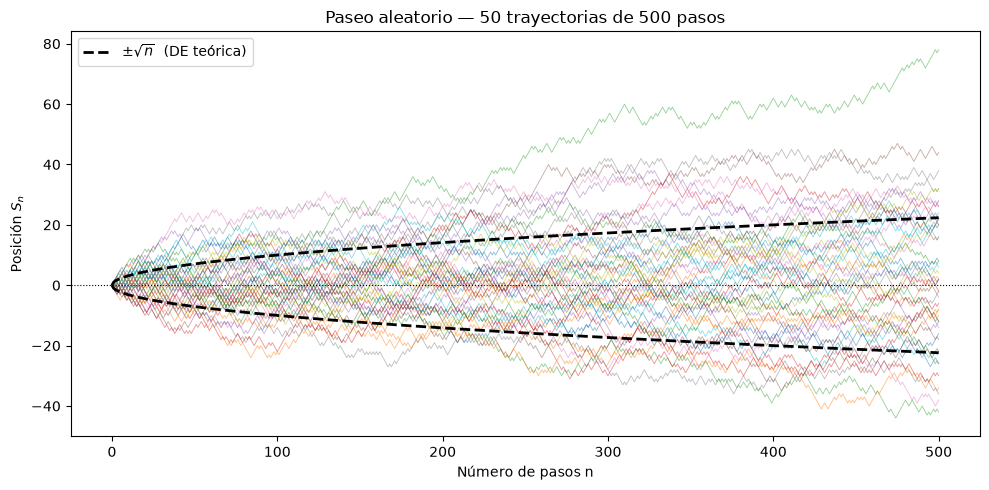

In [7]:
N_PASOS = 500
N_TRAY  = 50

trayectorias = simular_paseos(N_PASOS, N_TRAY, rng)  # shape: (50, 501)
pasos_eje = np.arange(N_PASOS + 1)
envolvente = np.sqrt(pasos_eje)

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(N_TRAY):
    ax.plot(pasos_eje, trayectorias[i], linewidth=0.6, alpha=0.5)

ax.plot(pasos_eje,  envolvente, 'k--', linewidth=2, label=r'$\pm\sqrt{n}$  (DE teórica)')
ax.plot(pasos_eje, -envolvente, 'k--', linewidth=2)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')

ax.set_xlabel('Número de pasos n')
ax.set_ylabel('Posición $S_n$')
ax.set_title(f'Paseo aleatorio — {N_TRAY} trayectorias de {N_PASOS} pasos')
ax.legend()
plt.tight_layout()
plt.show()

### Gráfico 2 — Distribución de posiciones finales

Simulamos 10.000 trayectorias de 500 pasos y representamos el histograma de $S_{500}$. Por el Teorema Central del Límite (Sección 3), $S_n / \sqrt{n}$ converge en distribución a una $\mathcal{N}(0,1)$ — la curva normal superpuesta confirma este resultado.

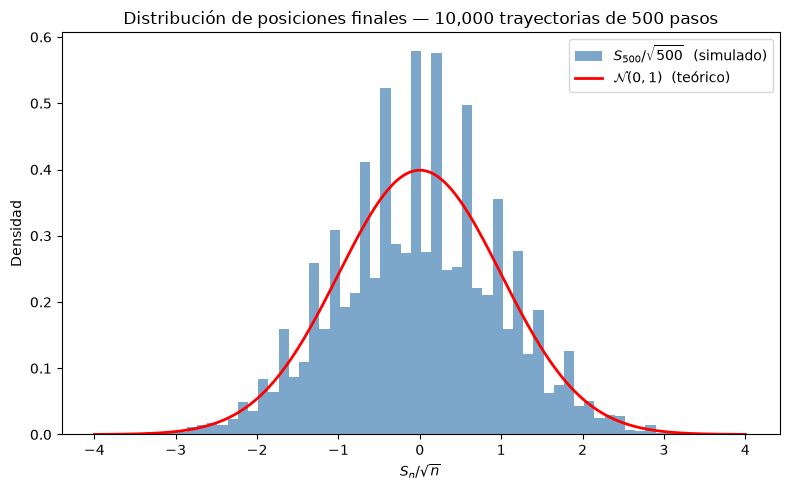

In [8]:
from scipy.stats import norm

N_PASOS_HIST = 500
N_TRAY_HIST  = 10_000

tray_hist   = simular_paseos(N_PASOS_HIST, N_TRAY_HIST, rng)
pos_finales = tray_hist[:, -1]           # S_500 para cada trayectoria
pos_norm    = pos_finales / np.sqrt(N_PASOS_HIST)   # S_n / √n → N(0,1)

x = np.linspace(-4, 4, 300)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pos_norm, bins=60, density=True, color='steelblue', alpha=0.7, label=r'$S_{500}/\sqrt{500}$  (simulado)')
ax.plot(x, norm.pdf(x), 'r-', linewidth=2, label=r'$\mathcal{N}(0,1)$  (teórico)')
ax.set_xlabel(r'$S_n / \sqrt{n}$')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribución de posiciones finales — {N_TRAY_HIST:,} trayectorias de {N_PASOS_HIST} pasos')
ax.legend()
plt.tight_layout()
plt.show()

## 2.4 Cierre de la sección

### Resultados obtenidos

- La dispersión de las trayectorias crece visiblemente como $\sqrt{n}$, confirmando $\text{DE}(S_n) = \sqrt{n}$.
- La distribución de posiciones finales $S_n / \sqrt{n}$ se ajusta con precisión a una $\mathcal{N}(0,1)$, anticipando el Teorema Central del Límite (Sección 3).

### Conexión con el Módulo 2

El movimiento browniano estándar $W_t$ es el límite continuo del paseo aleatorio: si definimos $W_t^{(n)} = S_{\lfloor nt \rfloor} / \sqrt{n}$, entonces $W_t^{(n)} \xrightarrow{d} W_t$ cuando $n \to \infty$ (Donsker, 1951). En la práctica, la discretización del GBM usa exactamente este resultado: cada incremento $\Delta W = W_{t+\Delta t} - W_t$ se distribuye como $\mathcal{N}(0, \Delta t)$, que es un paso de paseo aleatorio escalado por $\sqrt{\Delta t}$.

---

# Sección 3 — Teorema Central del Límite en simulación

## 3.1 Enunciado y significado

### Enunciado (Lindeberg–Lévy)

Sea $X_1, X_2, \ldots, X_N$ una sucesión de variables aleatorias i.i.d. con media $\mu = \mathbb{E}[X_i]$ y varianza finita $\sigma^2 = \text{Var}(X_i) < \infty$. Sea $\bar{X}_N = \frac{1}{N}\sum_{i=1}^{N} X_i$ el promedio muestral. Entonces:

$$
\frac{\bar{X}_N - \mu}{\sigma / \sqrt{N}} \xrightarrow{d} \mathcal{N}(0, 1) \quad \text{cuando } N \to \infty
$$

O equivalentemente, para $N$ suficientemente grande:

$$
\bar{X}_N \approx \mathcal{N}\!\left(\mu,\, \frac{\sigma^2}{N}\right)
$$

La notación $\xrightarrow{d}$ significa convergencia en distribución: la función de distribución acumulada del lado izquierdo converge punto a punto a la de una $\mathcal{N}(0,1)$.

### ¿Qué dice en palabras?

El resultado es sorprendente: **sin importar qué distribución tengan las $X_i$** — Bernoulli, uniforme, exponencial, cualquiera con varianza finita — el promedio de $N$ de ellas se comporta siempre como una variable normal cuando $N$ es grande. La distribución de origen desaparece; solo importan su media y su varianza.

### Por qué el TCL justifica Monte Carlo

En Monte Carlo estimamos $\mu = \mathbb{E}[f(X)]$ mediante el promedio $\bar{X}_N = \frac{1}{N}\sum_{i=1}^N f(X_i)$. El TCL garantiza que ese estimador sigue aproximadamente una distribución normal, lo que permite:

**1. Cuantificar el error:** la desviación típica del estimador es $\sigma/\sqrt{N}$, donde $\sigma^2 = \text{Var}(f(X))$. Este es exactamente el error estándar (SE) que calculamos en la Sección 1.

**2. Construir intervalos de confianza:** en una $\mathcal{N}(0,1)$ el 95% de la masa está entre $-1.96$ y $+1.96$, por lo que:

$$
\mathbb{P}\!\left(-1.96 \;\le\; \frac{\bar{X}_N - \mu}{\sigma/\sqrt{N}} \;\le\; 1.96\right) \approx 0.95
$$

Despejamos $\mu$ multiplicando todos los términos por $\sigma/\sqrt{N}$:

$$
\mathbb{P}\!\left(-1.96\cdot\frac{\sigma}{\sqrt{N}} \;\le\; \bar{X}_N - \mu \;\le\; 1.96\cdot\frac{\sigma}{\sqrt{N}}\right) \approx 0.95
$$

Y restando $\bar{X}_N$ y multiplicando por $-1$ (lo que invierte las desigualdades):

$$
\mathbb{P}\!\left(\bar{X}_N - 1.96\cdot\frac{\sigma}{\sqrt{N}} \;\le\; \mu \;\le\; \bar{X}_N + 1.96\cdot\frac{\sigma}{\sqrt{N}}\right) \approx 0.95
$$

Es decir, con probabilidad 95% el valor real $\mu$ está en el intervalo:

$$
\bar{X}_N \pm 1.96 \cdot \frac{\sigma}{\sqrt{N}}
$$

**3. Explicar el ritmo $O(1/\sqrt{N})$:** el $\sqrt{N}$ en el denominador del SE no es casual — es consecuencia directa del TCL. Para reducir el error a la mitad hay que cuadruplicar $N$, y esto es inevitable para cualquier estimador basado en $N$ muestras i.i.d.

## 3.2 Demostración empírica

Usamos variables Bernoulli(0.5) — solo toma valores 0 y 1, la más alejada de una normal posible — y mostramos que su promedio se parece cada vez más a una campana gaussiana conforme $N$ crece. Lo hacemos para $N = 1, 5, 30, 500$.

> **Nota:** el eje x no representa el número de caras sino el promedio normalizado $(\bar{X}_N - \mu)\,/\,(\sigma/\sqrt{N})$. El valor 0 significa que el resultado del experimento coincidió exactamente con la media esperada — con $N=500$ eso equivale a sacar aproximadamente 250 caras, no 0. Los extremos del eje (±4) representan resultados muy alejados de la media, que son cada vez menos probables conforme la campana se estrecha.

In [ ]:
N_MUESTRAS = 20_000
valores_N  = [1, 5, 30, 500]

mu_bern    = 0.5
sigma_bern = np.sqrt(0.5 * 0.5)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, N in zip(axes, valores_N):
    muestras      = rng.binomial(N, 0.5, size=N_MUESTRAS) / N
    muestras_norm = (muestras - mu_bern) / (sigma_bern / np.sqrt(N))

    ax.hist(muestras_norm, bins=50, density=True, color='steelblue', alpha=0.7)
    x = np.linspace(-4, 4, 300)
    ax.plot(x, norm.pdf(x), 'r-', linewidth=2)
    ax.set_title(f'N = {N}')
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 0.55)
    ax.set_xlabel(r'$(\bar{X}_N - \mu)\,/\,(\sigma/\sqrt{N})$')

axes[0].set_ylabel('Densidad')
fig.suptitle('Convergencia al TCL — promedio de N variables Bernoulli(0.5)', y=1.02)
plt.tight_layout()
plt.show()

## 3.3 Cierre de la sección

### Resultados obtenidos

- Con $N=1$ el histograma tiene forma de Bernoulli: dos barras en los extremos, nada en el centro.
- Con $N=5$ empieza a aparecer una campana pero todavía irregular.
- Con $N=30$ la aproximación normal ya es visualmente buena — de ahí que $N \ge 30$ se use habitualmente como regla práctica para aplicar el TCL.
- Con $N=500$ el histograma es prácticamente indistinguible de la curva normal teórica.

### Aplicación directa a Monte Carlo

En la Sección 1 estimamos $\pi$ con $N = 1\,000\,000$ muestras. El TCL garantiza que el estimador $\hat{\pi}_N$ sigue una $\mathcal{N}(\pi,\, \pi(4-\pi)/N)$, lo que permite construir el intervalo de confianza al 95%:

$$
\hat{\pi}_N \pm 1.96 \cdot \sqrt{\frac{\pi(4-\pi)}{N}}
$$

Este intervalo es la herramienta que convierte una estimación de Monte Carlo en un resultado estadísticamente riguroso — no un número suelto, sino un número con incertidumbre cuantificada.

---

# Cierre del Módulo 1

## Lo que hemos construido

Este módulo ha establecido las dos piezas conceptuales sobre las que se apoya todo el proyecto:

**1. Monte Carlo = simulación repetida + promedio**

La Sección 1 mostró el esquema canónico: para calcular una cantidad μ que no tiene forma cerrada, la expresas como una esperanza E[f(X)], generas N muestras independientes y promedias. La LGN garantiza la convergencia; el TCL cuantifica el error. Este esquema se repetirá en los Módulos 3 y 4 con funciones f de creciente complejidad financiera.

**2. Trayectoria aleatoria → movimiento browniano**

La Sección 2 construyó la intuición del paseo aleatorio: una sucesión de pasos independientes cuya dispersión crece como $\sqrt{n}$. En el límite continuo ese proceso se convierte en el movimiento browniano $W_t$, el ingrediente fundamental del modelo de precios que estudiaremos a continuación.

**3. El TCL como garantía estadística**

La Sección 3 justificó por qué el promedio de simulaciones siempre converge a una distribución normal, independientemente de la distribución de partida. Eso permite construir intervalos de confianza y afirmar con rigor cuánto error comete el estimador — algo imprescindible en cualquier aplicación financiera seria.

## Conexión con el Módulo 2

El Módulo 2 aplica el movimiento browniano al precio de un activo financiero. El modelo es el **movimiento browniano geométrico (GBM)**:

$$
S_t = S_0 \, e^{\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t}
$$

donde $S_t$ es el precio en el instante $t$, $\mu$ es la rentabilidad esperada, $\sigma$ es la volatilidad y $W_t$ es el movimiento browniano que acabamos de estudiar. La discretización de este proceso para simularlo en el ordenador usa exactamente el resultado de Donsker: cada incremento $\Delta W \sim \mathcal{N}(0, \Delta t)$.